# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [31]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
df = pd.read_csv("data/retailmax.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

In [33]:
# tu código aquí
import math

# Valor de phi usando la librería math
phi_libreria = (1 + math.sqrt(5)) / 2

# Función y derivada
def f(x):
    return x**2 - x - 1

def df(x):
    return 2*x - 1

# Método de Newton-Raphson
x = 1.5
iteraciones = 0

while x != phi_libreria:
    x = x - f(x) / df(x)
    iteraciones += 1

print("Aproximación de phi:", x)
print("Valor de phi con librería:", phi_libreria)
print("Iteraciones necesarias:", iteraciones)

Aproximación de phi: 1.618033988749895
Valor de phi con librería: 1.618033988749895
Iteraciones necesarias: 4


### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


<Figure size 800x600 with 0 Axes>

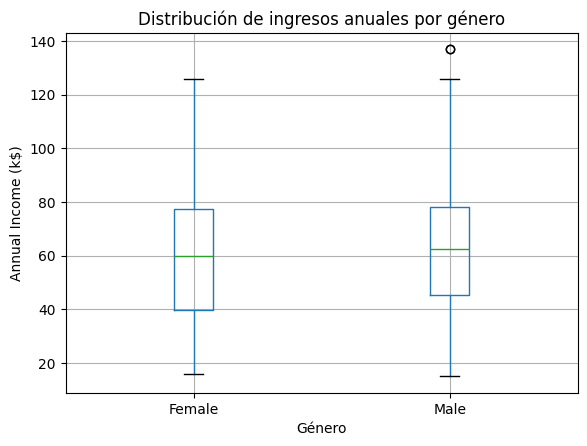

In [40]:
# tu código aquí
df = pd.read_csv("data/retailmax.csv")
df.head()

# Verificar columnas disponibles
print(df.columns)

# Boxplot: Annual Income por género
plt.figure(figsize=(8, 6))

df.boxplot(
    column='Annual Income (k$)',
    by='Gender',
    grid=True
)

plt.title('Distribución de ingresos anuales por género')
plt.suptitle('')
plt.xlabel('Género')
plt.ylabel('Annual Income (k$)')

plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

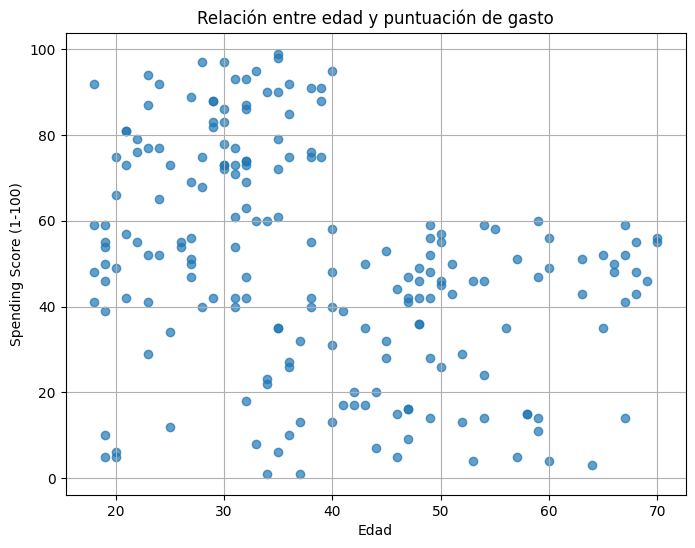

In [49]:
# tu código aquí
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Age'],
    df['Spending Score (1-100)'],
    alpha=0.7
)

plt.title('Relación entre edad y puntuación de gasto')
plt.xlabel('Edad')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)

plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

Coeficiente de correlación: 0.0099


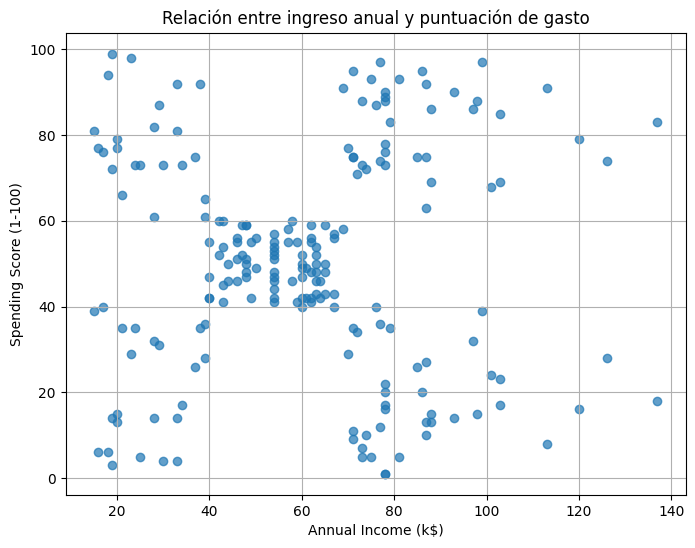

Existe una correlación positiva débil.


In [64]:
# tu código aquí
# Calcular correlación
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])

print(f"Coeficiente de correlación: {correlacion:.4f}")

# Gráfica de dispersión
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    alpha=0.7
)

plt.title('Relación entre ingreso anual y puntuación de gasto')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)

plt.show()

if correlacion > 0.7:
    print("Existe una correlación positiva fuerte.")
elif correlacion > 0.3:
    print("Existe una correlación positiva moderada.")
elif correlacion > 0:
    print("Existe una correlación positiva débil.")
elif correlacion < -0.7:
    print("Existe una correlación negativa fuerte.")
elif correlacion < -0.3:
    print("Existe una correlación negativa moderada.")
elif correlacion < 0:
    print("Existe una correlación negativa débil.")
else:
    print("No existe correlación lineal.")


### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

<Figure size 1000x600 with 0 Axes>

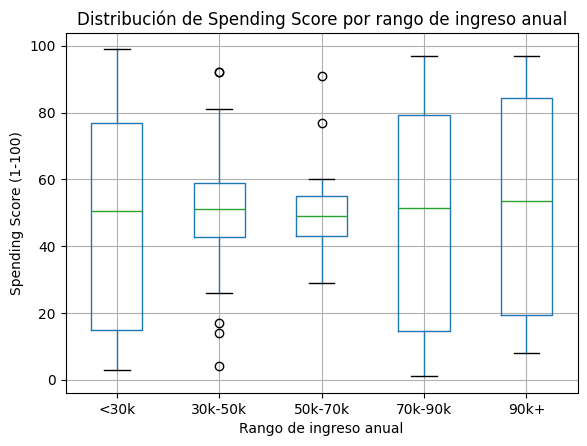

Income Group
<30k       32
30k-50k    42
50k-70k    52
70k-90k    52
90k+       22
Name: count, dtype: int64

In [71]:
# tu código aquí
# Crear rangos de ingresos anuales
df['Income Group'] = pd.cut(
    df['Annual Income (k$)'],
    bins=[0, 30, 50, 70, 90, 150],
    labels=['<30k', '30k-50k', '50k-70k', '70k-90k', '90k+']
)

# Boxplot de Spending Score por grupo de ingreso
plt.figure(figsize=(10, 6))

df.boxplot(
    column='Spending Score (1-100)',
    by='Income Group',
    grid=True
)

plt.title('Distribución de Spending Score por rango de ingreso anual')
plt.suptitle('')
plt.xlabel('Rango de ingreso anual')
plt.ylabel('Spending Score (1-100)')

plt.show()

df['Income Group'].value_counts().sort_index()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

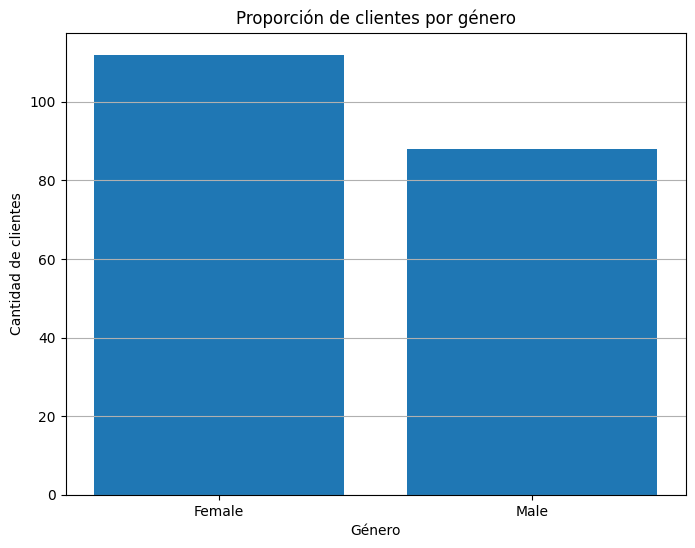

Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


In [80]:
# tu código aquí
# Contar clientes por género
gender_counts = df['Gender'].value_counts()

# Gráfica de barras
plt.figure(figsize=(8, 6))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title('Proporción de clientes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')
plt.grid(axis='y')

plt.show()

# Mostrar proporciones en porcentaje
gender_percentages = df['Gender'].value_counts(normalize=True) * 100
print(gender_percentages)

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

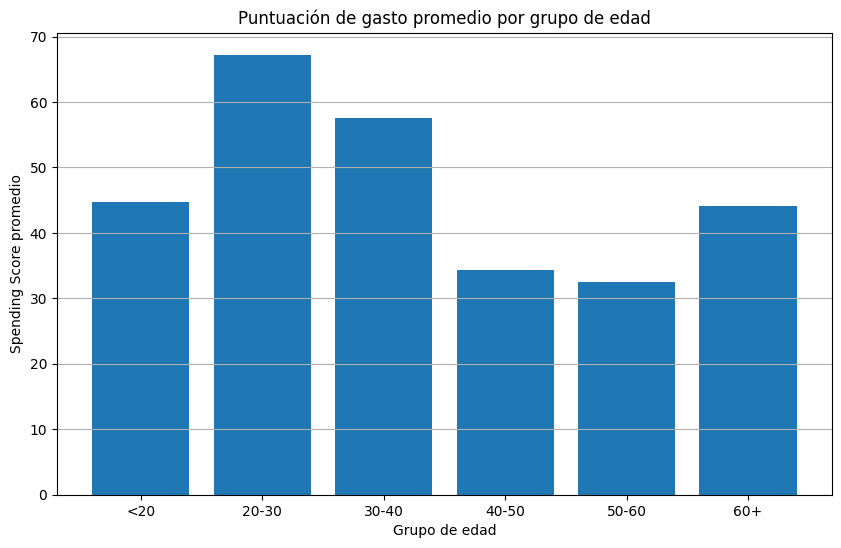

Age Group
<20      44.647059
20-30    67.222222
30-40    57.500000
40-50    34.394737
50-60    32.521739
60+      44.176471
Name: Spending Score (1-100), dtype: float64
El grupo de edad con mayor gasto promedio es 20-30, con un Spending Score promedio de 67.22.


In [89]:
# tu código aquí
# Crear rangos de edad
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 20, 30, 40, 50, 60, 100],
    labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+']
)

# Calcular promedio de Spending Score por grupo de edad
avg_spending_by_age = df.groupby('Age Group')['Spending Score (1-100)'].mean()

# Gráfica de barras
plt.figure(figsize=(10, 6))

plt.bar(
    avg_spending_by_age.index.astype(str),
    avg_spending_by_age.values
)

plt.title('Puntuación de gasto promedio por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Spending Score promedio')
plt.grid(axis='y')

plt.show()

# Mostrar valores
print(avg_spending_by_age)

grupo_mayor_gasto = avg_spending_by_age.idxmax()
mayor_promedio = avg_spending_by_age.max()

print(f"El grupo de edad con mayor gasto promedio es {grupo_mayor_gasto}, con un Spending Score promedio de {mayor_promedio:.2f}.")

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

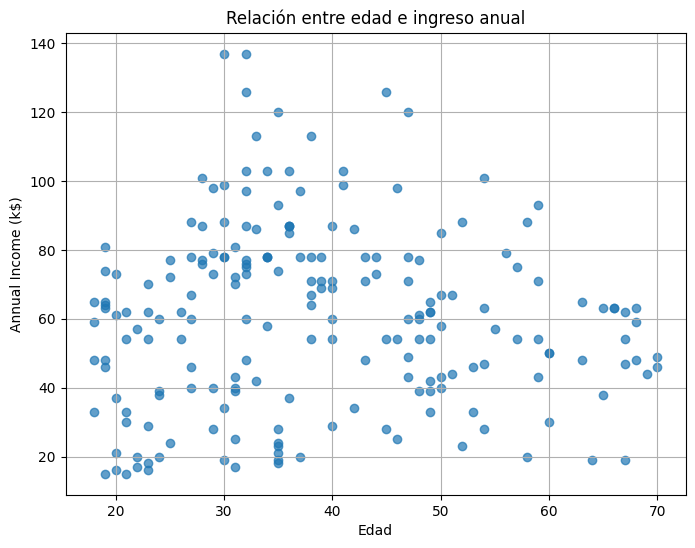

Coeficiente de correlación: -0.0124


In [96]:
# tu código aquí
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    alpha=0.7
)

plt.title('Relación entre edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Annual Income (k$)')
plt.grid(True)

plt.show()

correlacion = df['Age'].corr(df['Annual Income (k$)'])
print(f"Coeficiente de correlación: {correlacion:.4f}")

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

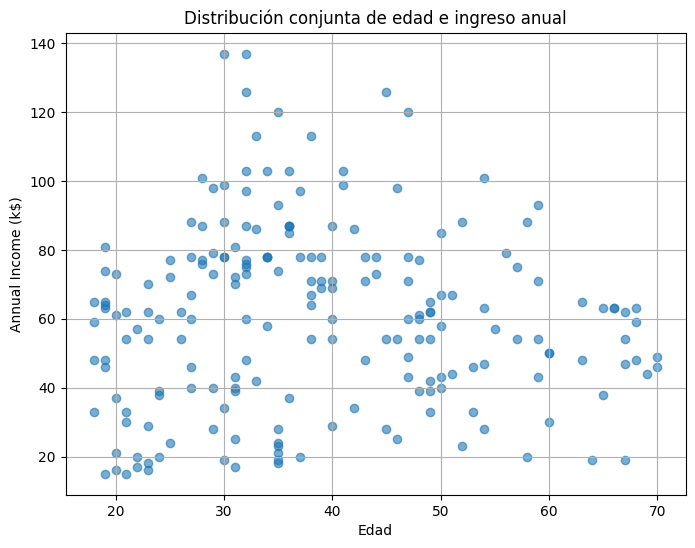

In [100]:
# tu código aquí
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    alpha=0.6
)

plt.title('Distribución conjunta de edad e ingreso anual')
plt.xlabel('Edad')
plt.ylabel('Annual Income (k$)')
plt.grid(True)

plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

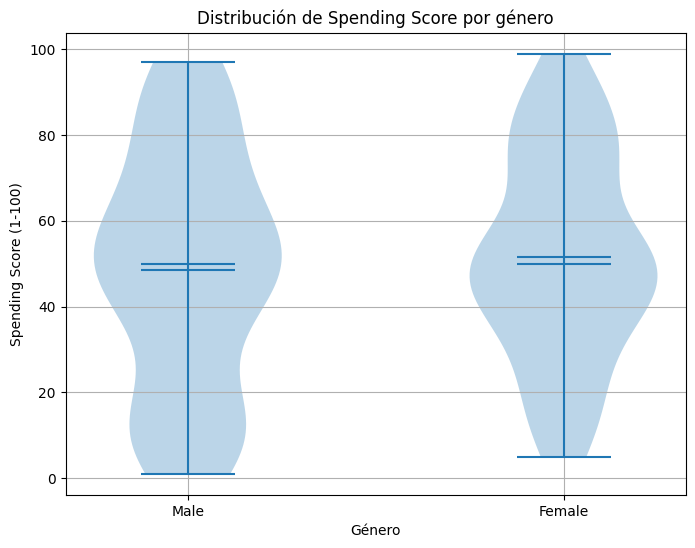

In [102]:
# tu código aquí
# Separar Spending Score por género
male_score = df[df['Gender'] == 'Male']['Spending Score (1-100)']
female_score = df[df['Gender'] == 'Female']['Spending Score (1-100)']

plt.figure(figsize=(8, 6))

plt.violinplot([male_score, female_score], showmeans=True, showmedians=True)

plt.xticks([1, 2], ['Male', 'Female'])
plt.title('Distribución de Spending Score por género')
plt.xlabel('Género')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)

plt.show()